# HW 11
# Minh Truong
# 141225

Perform the following activities in Python:    

- Get the dataset - pick any one of the datasets from the NLP Datasets folder or from any other online resource that interests you.
- Load the .csv file into a data frame in Python.
- You can use any package of your choice in Python - NLTK, VADER etc.,
- Import necessary libraries.
- Preprocess data if needed.
- Perform Sentiment Analysis.
- Classify the information into Positive, Negative, or Neutral sentiments.
- Classify the text categorically into emotions - anger, disgust, fear, joy, sadness, and surprise etc.,
- Generate bar graphs for sentiment and emotion.
- Generate a word cloud.
- Provide conclusions based on the analysis.

## Import necessary libraries.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from nrclex import NRCLex
import nltk
import re
import subprocess
subprocess.run(['python', '-m', 'textblob.download_corpora'])

# Download required NLTK resources
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/mtruong/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mtruong/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/mtruong/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mtruong/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Get the Dataset

## Load the .csv file into a data frame in Python.

In [16]:
# Load dataset
df = pd.read_csv('/Users/mtruong/python-projects/BZAN 6355/Original recipes.csv')
df.head()

,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,9/16/2005,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,6/17/2002,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2/25/2005,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,4/14/2003,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,10/25/2002,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


## Describe the Data

In [17]:
# Summary statistics
df.describe()

,id,minutes,contributor_id,n_steps,n_ingredients
count,231637.000000,2.316370e+05,2.316370e+05,231637.000000,231637.000000
mean,222014.708984,9.398546e+03,5.534885e+06,9.765499,9.051153
std,141206.635626,4.461963e+06,9.979141e+07,5.995128,3.734796
min,38.000000,0.000000e+00,2.700000e+01,0.000000,1.000000
25%,99944.000000,2.000000e+01,5.690500e+04,6.000000,6.000000
50%,207249.000000,4.000000e+01,1.736140e+05,9.000000,9.000000
75%,333816.000000,6.500000e+01,3.982750e+05,12.000000,11.000000
max,537716.000000,2.147484e+09,2.002290e+09,145.000000,43.000000


In [18]:
# Check for missing values
df.isnull().sum()

name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingredients        0
dtype: int64

## Preprocess data if needed.
- Drop rows with missing descriptions
- Sample 5,000 rows for performance
- Clean text

In [19]:
# Drop missing descriptions and sample 5,000 rows for performance
df = df[['name', 'description']].dropna().sample(5000, random_state=42).reset_index(drop=True)

# Clean text by lowercase text and removing punctuation/numbers
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

df['clean_description'] = df['description'].apply(clean_text)
df.head()

,name,description,clean_description
0,auntie fanny s pea and mint mash,"this is still only peas, tastes of peas, and d...",this is still only peas tastes of peas and doe...
1,honey roasted plums with thyme,"excellent, elegant desert, especially when ser...",excellent elegant desert especially when serve...
2,egg muffin sandwich,"just like mcdonalds, but you can control the i...",just like mcdonalds but you can control the in...
3,splendid chicken and corn,i tried a recipe very similar to this and love...,i tried a recipe very similar to this and love...
4,applesauce raisin muffins,this muffin recipe is a hit with all my family...,this muffin recipe is a hit with all my family...


## Perform Sentiment Analysis.
### Classify the information into Positive, Negative, or Neutral sentiments.
Decided to use  VADER because it is designed for short, informal text and scores each description
as positive, negative, or neutral based on compound score.

In [32]:
# Initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Compute compound sentiment score for each description
# compound ranges from -1 (negative) to +1 (positive)
df['compound'] = df['clean_description'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Apply standard VADER thresholds to label sentiment
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['compound'].apply(classify_sentiment)
df[['description', 'sentiment', 'compound']].head(10)

,description,sentiment,compound
0,"this is still only peas, tastes of peas, and d...",Positive,0.7962
1,"excellent, elegant desert, especially when ser...",Positive,0.7783
2,"just like mcdonalds, but you can control the i...",Positive,0.8126
3,i tried a recipe very similar to this and love...,Positive,0.9246
4,this muffin recipe is a hit with all my family...,Positive,0.8360
5,for this recipe the macaroni is cooked right i...,Positive,0.1406
6,quick and tasty way to serve chicken breasts. ...,Positive,0.2732
7,this can also be made using chicken pieces or ...,Positive,0.9563
8,"from publix (supermarket)apron's, simple meal ...",Positive,0.5859
9,"always a crowd pleaser, and kid pleaser too!\r...",Positive,0.9300


## Classify Emotions
### Classify the text categorically into emotions - anger, disgust, fear, joy, sadness, and surprise etc.,

In [47]:
# Tokenize text and sum NRC emotion scores across all words
# Removes 'positive'/'negative' because these are sentiment labels, not emotions
def get_emotion(text):
    try:
        words = word_tokenize(str(text).lower())
        scores = {}
        for word in words:
            emotion_obj = NRCLex(word)          # Initialize NRCLex with single word
            emotion_obj.load_raw_text(word)     # Explicitly load word as raw text
            for k, v in emotion_obj.affect_frequencies.items():
                if v > 0:
                    scores[k] = scores.get(k, 0) + v  # Accumulate emotion scores
        scores.pop('positive', None)
        scores.pop('negative', None)
        if not scores or max(scores.values()) < 0.5:  # Ignore weak signals
            return 'none'
        return max(scores, key=scores.get)             # Return dominant emotion
    except Exception:
        return 'none'

df['emotion'] = df['clean_description'].apply(get_emotion)
df[['description', 'sentiment', 'emotion']].head(10)

,description,sentiment,emotion
0,"this is still only peas, tastes of peas, and d...",Positive,none
1,"excellent, elegant desert, especially when ser...",Positive,none
2,"just like mcdonalds, but you can control the i...",Positive,none
3,i tried a recipe very similar to this and love...,Positive,none
4,this muffin recipe is a hit with all my family...,Positive,none
5,for this recipe the macaroni is cooked right i...,Positive,none
6,quick and tasty way to serve chicken breasts. ...,Positive,none
7,this can also be made using chicken pieces or ...,Positive,none
8,"from publix (supermarket)apron's, simple meal ...",Positive,none
9,"always a crowd pleaser, and kid pleaser too!\r...",Positive,none


In [68]:
def get_emotion(text):
    try:
        word_list = word_tokenize(str(text).lower())
        scores = {}
        lexicon = NRCLex('a').__lexicon__
        for word in word_list:
            if word in lexicon:
                # Lexicon values are lists of emotion strings, not dicts
                for emotion in lexicon[word]:
                    if emotion not in ('positive', 'negative'):
                        scores[emotion] = scores.get(emotion, 0) + 1
        if not scores:
            return 'none'
        return max(scores, key=scores.get)
    except Exception:
        # Suppress error output to prevent thousands of repeated print lines
        return 'none'

df['emotion'] = df['clean_description'].apply(get_emotion)
print(df['emotion'].value_counts())

emotion
joy             1533
anticipation    1226
none             952
trust            725
fear             166
anger            162
disgust          103
sadness           89
surprise          44
Name: count, dtype: int64


In [69]:
lexicon = NRCLex('a').__lexicon__
# Check what a single entry looks like
sample_key = list(lexicon.keys())[0]
print(sample_key, lexicon[sample_key])

abacus ['trust']


In [70]:
def get_emotion(text):
    try:
        word_list = word_tokenize(str(text).lower())
        scores = {}
        lexicon = NRCLex('a').__lexicon__
        for word in word_list:
            if word in lexicon:
                for emotion in lexicon[word]:                        # List of emotion strings
                    if emotion not in ('positive', 'negative'):
                        scores[emotion] = scores.get(emotion, 0) + 1 # Count each hit
        if not scores:
            return 'none'
        return max(scores, key=scores.get)
    except Exception as e:
        print(e)
        return 'none'

df['emotion'] = df['clean_description'].apply(get_emotion)
print(df['emotion'].value_counts())

emotion
joy             1533
anticipation    1226
none             952
trust            725
fear             166
anger            162
disgust          103
sadness           89
surprise          44
Name: count, dtype: int64


## Generate bar graphs for sentiment and emotion.

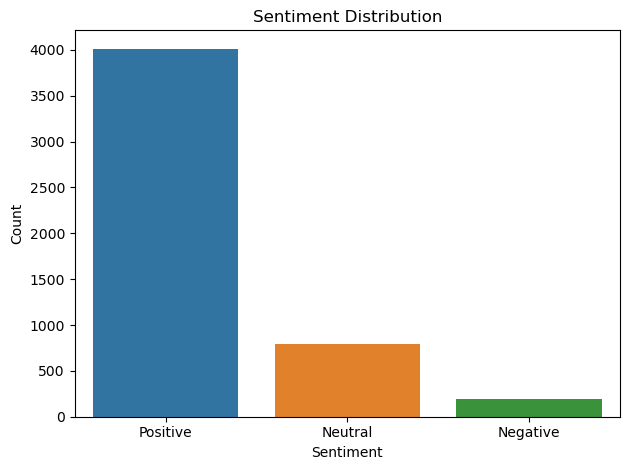

In [71]:
# Sentiment Distribution Bar Graph
# Count occurrences of each sentiment label
sentiment_counts = df['sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['sentiment', 'count']

sns.barplot(
    data=sentiment_counts,
    x='sentiment',
    y='count',
    hue='sentiment', # Colors bars by sentiment category
    palette='tab10',
    legend=False # Suppress redundant legend
)
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

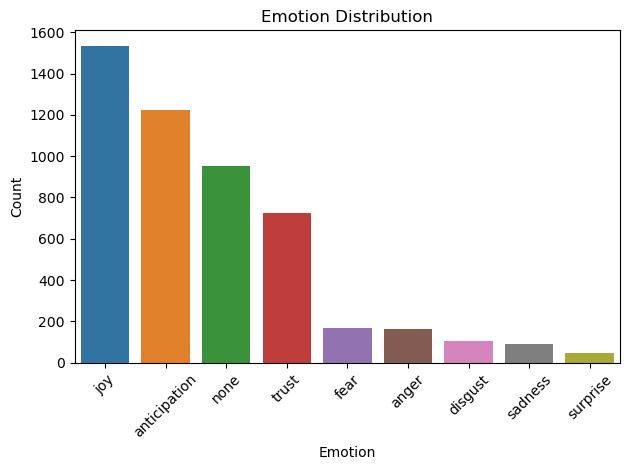

In [72]:
# Emotion Distribution Bar Graph
# Count occurrences of each emotion label
emotion_counts = df['emotion'].value_counts().reset_index()
emotion_counts.columns = ['emotion', 'count']

sns.barplot(
    data=emotion_counts,
    x='emotion',
    y='count',
    hue='emotion', # Colors bars by emotion category
    palette='tab10',
    legend=False # Suppress redundant legend
)
plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45) # Rotate labels to prevent overlap
plt.tight_layout()
plt.show()

## Generate a word cloud.

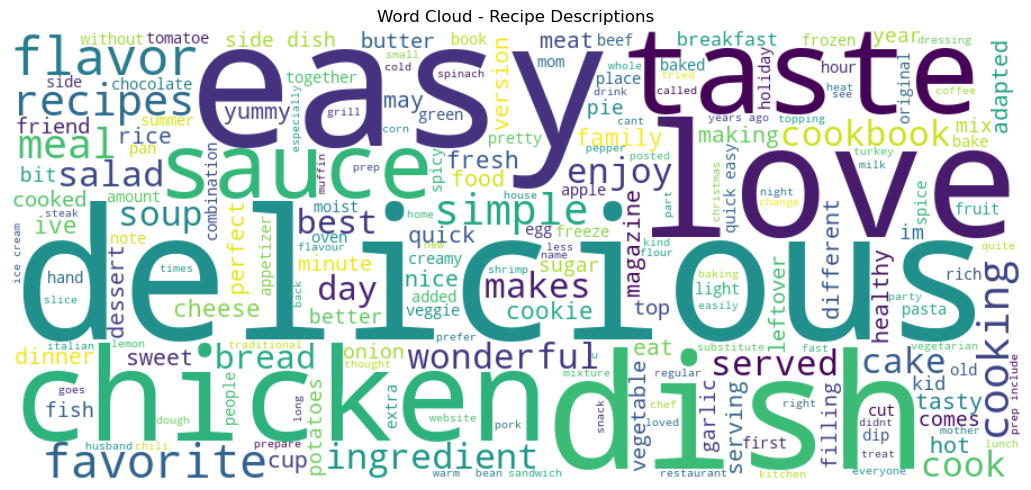

In [73]:
# Word cloud (most frequent words in all descriptions)
stop_words = set(stopwords.words('english'))

# Add domain-specific filler words that add no analytical value
custom_stopwords = stop_words | {'recipe', 'make', 'use', 'add', 'get',
                                  'want', 'one', 'also', 'well', 'even',
                                  'really', 'little', 'dont', 'used', 'made',
                                  'using', 'time', 'way', 'much', 'many',
                                  'would', 'could', 'like', 'great', 'good',
                                  'need', 'go', 'try', 'work', 'look',
                                  'serve', 'found', 'came', 'think', 'got',
                                  'put', 'come', 'find', 'take', 'say',
                                  'know', 'give', 'call', 'keep', 'still',
                                  'two', 'every', 'another', 'something',
                                  'sure', 'lot', 'never', 'always', 'alway',
                                  'thing', 'instead', 'usually', 'enough'}

all_text = ' '.join(df['clean_description'])

# Remove stopwords and filler words to surface meaningful terms
filtered_text = ' '.join([w for w in all_text.split() if w not in custom_stopwords])

# Generate and display word cloud
# The larger words are the ones that appear more frequently
wordcloud = WordCloud(width=900, height=400, background_color='white').generate(filtered_text)
plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Recipe Descriptions')
plt.tight_layout()
plt.show()

## Conclusion
Provide conclusions based on the analysis.

**Conclusion:**
Sentiment analysis on these recipe descriptions is overwhelmingly positive because it reflects the foods that the authors enjoy, love, and would recommend.  The most dominant emotions detected were joy and anticipation, which reflect the enthusiastic language used commonly in culinary writing. The word cloud supports this by highlighting descriptive and appealing language as the primary sentiment driver, with words like "delicious," "love," "flavor," "favorite," "taste," and "easy" appearing most prominently across descriptions.